**Step-01**

In [1]:
# ============================================================
# STEP-01: Data Ingestion and AAMI Mapping
# ============================================================

# !pip install wfdb scikit-learn imbalanced-learn matplotlib seaborn -q
!pip install wfdb
import os
import pickle
import numpy as np
import wfdb

# --- AAMI standard 5-class mapping (identical to DST-ECG / DT pipeline) ---
AAMI_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V',
    'F':'F',
    '/':'Q','f':'Q','Q':'Q',
}

CLASS2IDX  = {'N':0, 'S':1, 'V':2, 'F':3, 'Q':4}
IDX2CLASS  = {0:'N', 1:'S', 2:'V', 3:'F', 4:'Q'}
CLASS_NAMES = ['N','S','V','F','Q']

# All 48 MIT-BIH records (identical to DST-ECG / DT pipeline)
MIT_BIH_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]


def load_record(record_id, data_dir='mitdb'):
    path   = os.path.join(data_dir, record_id)
    record = wfdb.rdrecord(path)
    annot  = wfdb.rdann(path, 'atr')
    return record.p_signal, record.fs, annot.sample, annot.symbol


def extract_beats(signal, fs, r_peaks, symbols, before=150, after=150):
    
    beats, labels, peak_positions = [], [], []
    win = before + after
    for peak, sym in zip(r_peaks, symbols):
        aami = AAMI_MAP.get(sym)
        if aami is None:
            continue
        start, end = peak - before, peak + after
        if start < 0 or end > signal.shape[0]:
            continue
        beats.append(signal[start:end, :])
        labels.append(CLASS2IDX[aami])
        peak_positions.append(peak)          
    if len(labels) == 0:
        return (np.empty((0, win, 2), dtype=np.float32),
                np.empty((0,), dtype=np.int64),
                np.empty((0,), dtype=np.int64))
    return (np.array(beats, dtype=np.float32),
            np.array(labels, dtype=np.int64),
            np.array(peak_positions, dtype=np.int64))  # <-- NEW


def download_and_extract():
    os.makedirs('mitdb', exist_ok=True)
    os.makedirs('processed', exist_ok=True)

    if os.path.exists('processed/subject_data.pkl'):
        print('subject_data.pkl already exists — skipping download.')
        with open('processed/subject_data.pkl','rb') as f:
            return pickle.load(f)

    print('Downloading MIT-BIH...')
    wfdb.dl_database('mitdb', dl_dir='mitdb',
                     records=MIT_BIH_RECORDS, overwrite=False)
    print('Download complete.')

    subject_data = {}
    for rec in MIT_BIH_RECORDS:
        signal, fs, r_peaks, symbols = load_record(rec)
        beats, labels, peak_positions = extract_beats(   
            signal, fs, r_peaks, symbols
        )
        subject_data[rec] = {
            'beats': beats,
            'labels': labels,
            'r_peaks': peak_positions,   
            'fs': fs                     
        }
        if len(labels) > 0:
            print(f'  {rec}: {len(labels)} beats | {np.bincount(labels, minlength=5)}')

    with open('processed/subject_data.pkl','wb') as f:
        pickle.dump(subject_data, f)
    print('Saved: processed/subject_data.pkl')
    return subject_data


subject_data = download_and_extract()
print(f'\nLoaded {len(subject_data)} records.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.0 MB/s eta 0:00:0000:01
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record l

**Step-02**

In [2]:
# ============================================================
# STEP-02: Leak-Free LOSO Fold Builder
# ============================================================

def fit_normalize_train(X_train):
    """Compute mean/std on training data only. Shape: (N, C, T)"""
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
    return (X_train - mean) / std, mean, std


def normalize_test(X_test, mean, std):
    return (X_test - mean) / std


def build_patient_groups(record_ids):
    """Map each record_id to a patient_id, merging the one known
    same-patient pair (201, 202) into a single patient group."""
    patient_of = {r: r for r in record_ids}  # default: record_id == patient_id

    if '201' in patient_of and '202' in patient_of:
        patient_of['202'] = '201'  # 202 belongs to the same patient as 201

    groups = {}
    for r, pid in patient_of.items():
        groups.setdefault(pid, []).append(r)
    return groups  # {patient_id: [record_id, ...]}


def build_loso_folds(subject_data):
    """True leave-one-SUBJECT-out folds: all records belonging to the
    same patient are held out together, so no patient's beats ever
    appear in both the training and test sets of a fold."""
    record_ids = list(subject_data.keys())
    patient_groups = build_patient_groups(record_ids)
    patient_ids = list(patient_groups.keys())

    folds = []
    for i, test_patient in enumerate(patient_ids):
        test_records  = patient_groups[test_patient]
        train_records = [r for r in record_ids if r not in test_records]

        X_train_list = [subject_data[r]['beats']
                        for r in train_records
                        if subject_data[r]['beats'].shape[0] > 0]
        y_train_list = [subject_data[r]['labels']
                        for r in train_records
                        if subject_data[r]['beats'].shape[0] > 0]

        X_test_list = [subject_data[r]['beats']
                       for r in test_records
                       if subject_data[r]['beats'].shape[0] > 0]
        y_test_list = [subject_data[r]['labels']
                       for r in test_records
                       if subject_data[r]['beats'].shape[0] > 0]

        if len(X_train_list) == 0 or len(X_test_list) == 0:
            print(f'Skipping fold {test_patient} (empty)')
            continue

        X_train = np.concatenate(X_train_list, axis=0)  # (N, 300, 2)
        y_train = np.concatenate(y_train_list, axis=0)
        X_test  = np.concatenate(X_test_list, axis=0)   # (M, 300, 2)
        y_test  = np.concatenate(y_test_list, axis=0)

        X_train = X_train.transpose(0, 2, 1)  # (N, 2, 300)
        X_test  = X_test.transpose(0, 2, 1)

        X_train_norm, mean, std = fit_normalize_train(X_train)
        X_test_norm             = normalize_test(X_test, mean, std)

        folds.append({
            'test_id'   : '+'.join(test_records),  # e.g. "201+202"
            'patient_id': test_patient,
            'X_train'   : X_train_norm.astype(np.float32),
            'y_train'   : y_train.astype(np.int64),
            'X_test'    : X_test_norm.astype(np.float32),
            'y_test'    : y_test.astype(np.int64),
        })
        print(f"Fold {i+1:02d} | test_patient={test_patient} "
              f"(records={'+'.join(test_records)}) | "
              f"train={X_train_norm.shape[0]} | test={X_test_norm.shape[0]}")
    return folds


folds = build_loso_folds(subject_data)
print(f'\nTotal folds: {len(folds)} (true patient-independent)')

Fold 01 | test_patient=100 (records=100) | train=107173 | test=2271
Fold 02 | test_patient=101 (records=101) | train=107580 | test=1864
Fold 03 | test_patient=102 (records=102) | train=107259 | test=2185
Fold 04 | test_patient=103 (records=103) | train=107361 | test=2083
Fold 05 | test_patient=104 (records=104) | train=107217 | test=2227
Fold 06 | test_patient=105 (records=105) | train=106872 | test=2572
Fold 07 | test_patient=106 (records=106) | train=107417 | test=2027
Fold 08 | test_patient=107 (records=107) | train=107308 | test=2136
Fold 09 | test_patient=108 (records=108) | train=107682 | test=1762
Fold 10 | test_patient=109 (records=109) | train=106914 | test=2530
Fold 11 | test_patient=111 (records=111) | train=107320 | test=2124
Fold 12 | test_patient=112 (records=112) | train=106907 | test=2537
Fold 13 | test_patient=113 (records=113) | train=107650 | test=1794
Fold 14 | test_patient=114 (records=114) | train=107565 | test=1879
Fold 15 | test_patient=115 (records=115) | train

**Step-03**

In [3]:
# ============================================================
# STEP-03: Fold-Local Normalization and Imbalance Inspection
# ============================================================

from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


def get_class_weight_dict(y_train):
    """
    Compute sklearn-style balanced class weights
    from TRAINING data only.
    """

    classes = np.unique(y_train)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    return {
        int(cls): float(w)
        for cls, w in zip(classes, weights)
    }


def print_fold_statistics(fold):
    """
    Display fold-specific class distribution and weights.
    """

    y_train = fold["y_train"]

    print("=" * 60)
    print("Training Class Distribution")
    print("=" * 60)

    counts = Counter(y_train)

    for cls_idx in range(5):
        cls_name = CLASS_NAMES[cls_idx]
        count = counts.get(cls_idx, 0)

        print(
            f"Class {cls_name} ({cls_idx}) : {count}"
        )

    class_weights = get_class_weight_dict(y_train)

    print("\nBalanced Class Weights")
    print("-" * 60)

    for cls_idx in range(5):
        cls_name = CLASS_NAMES[cls_idx]

        if cls_idx in class_weights:
            print(
                f"Class {cls_name} ({cls_idx}) : "
                f"{class_weights[cls_idx]:.4f}"
            )

    return class_weights


# ============================================================
# Example: inspect first fold
# ============================================================

fold0 = folds[0]

class_weights = print_fold_statistics(fold0)

print("\nClass Weight Dictionary:")
print(class_weights)

# NOTE: KNN (sklearn's KNeighborsClassifier) has no native
# `class_weight` parameter — unlike DecisionTreeClassifier.
# Imbalance is therefore handled the same way as in the DT
# pipeline via fold-local SMOTE on the TRAINING set only
# (see Step-05). This keeps the imbalance-handling strategy
# identical across both models for a fair comparison.


Training Class Distribution
Class N (0) : 88351
Class S (1) : 2748
Class V (2) : 7234
Class F (3) : 802
Class Q (4) : 8038

Balanced Class Weights
------------------------------------------------------------
Class N (0) : 0.2426
Class S (1) : 7.8001
Class V (2) : 2.9630
Class F (3) : 26.7264
Class Q (4) : 2.6667

Class Weight Dictionary:
{0: 0.24260732759108555, 1: 7.800072780203784, 2: 2.963035664915676, 3: 26.72643391521197, 4: 2.6666583727295348}


**Step-04**

In [4]:
# ============================================================
# STEP-04: DUAL-SCALE HAND-CRAFTED FEATURE EXTRACTION
# ============================================================

import numpy as np
from scipy.stats import skew, kurtosis


# ============================================================
# SAFE STATISTICAL HELPERS  (unchanged)
# ============================================================

def safe_mean(x):
    return float(np.mean(x))

def safe_std(x):
    return float(np.std(x))

def safe_min(x):
    return float(np.min(x))

def safe_max(x):
    return float(np.max(x))

def safe_range(x):
    return float(np.max(x) - np.min(x))

def safe_rms(x):
    return float(np.sqrt(np.mean(x ** 2)))

def safe_skew(x):
    value = skew(x, bias=False)
    if not np.isfinite(value):
        return 0.0
    return float(value)

def safe_kurtosis(x):
    value = kurtosis(x, bias=False)
    if not np.isfinite(value):
        return 0.0
    return float(value)

def safe_median(x):
    return float(np.median(x))

def safe_iqr(x):
    q75, q25 = np.percentile(x, [75, 25])
    return float(q75 - q25)

def safe_energy(x):
    return float(np.mean(x ** 2))

def safe_zero_crossing_rate(x):
    if len(x) < 2:
        return 0.0
    signs = np.sign(x)
    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]
    crossings = np.sum(signs[1:] != signs[:-1])
    return float(crossings / max(1, len(x) - 1))

def safe_mean_abs_diff(x):
    if len(x) < 2:
        return 0.0
    return float(np.mean(np.abs(np.diff(x))))

def safe_std_diff(x):
    if len(x) < 2:
        return 0.0
    return float(np.std(np.diff(x)))

def safe_correlation(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if len(x) != len(y):
        return 0.0
    if len(x) < 2:
        return 0.0
    sx = np.std(x)
    sy = np.std(y)
    if sx < 1e-12 or sy < 1e-12:
        return 0.0
    value = np.corrcoef(x, y)[0, 1]
    if not np.isfinite(value):
        return 0.0
    return float(value)


# ============================================================
# INTRA-BEAT MORPHOLOGY  (38-D)  —  UNCHANGED
# ============================================================

def extract_single_lead_features(signal):
    signal = np.asarray(signal, dtype=np.float64)
    signal = np.nan_to_num(signal, nan=0.0, posinf=0.0, neginf=0.0)

    features = []
    features.append(safe_mean(signal))
    features.append(safe_std(signal))
    features.append(safe_min(signal))
    features.append(safe_max(signal))
    features.append(safe_range(signal))
    features.append(safe_rms(signal))
    features.append(safe_median(signal))
    features.append(safe_iqr(signal))
    features.append(safe_skew(signal))
    features.append(safe_kurtosis(signal))
    features.append(safe_energy(signal))
    features.append(safe_zero_crossing_rate(signal))
    features.append(safe_mean_abs_diff(signal))
    features.append(safe_std_diff(signal))
    features.append(float(np.max(np.abs(signal))))
    features.append(float(np.mean(np.abs(signal))))

    peak_position = np.argmax(np.abs(signal))
    if len(signal) > 1:
        peak_position = peak_position / (len(signal) - 1)
    else:
        peak_position = 0.0
    features.append(float(peak_position))

    t = np.arange(len(signal), dtype=np.float64)
    if len(signal) > 1 and np.std(t) > 0:
        slope = np.polyfit(t, signal, 1)[0]
    else:
        slope = 0.0
    if not np.isfinite(slope):
        slope = 0.0
    features.append(float(slope))

    return np.asarray(features, dtype=np.float32)


def extract_features(X):
    """
    Extract 38 intra-beat morphology features.
    X : (N, 2, 300)  ->  (N, 38)
    """
    X = np.asarray(X)

    if X.ndim != 3:
        raise ValueError(f"Expected X with 3 dimensions (N, 2, 300), but received shape {X.shape}")
    if X.shape[1] != 2:
        raise ValueError(f"Expected 2 ECG channels/leads, but received {X.shape[1]}")
    if X.shape[2] != 300:
        raise ValueError(f"Expected 300 samples per beat, but received {X.shape[2]}")

    feature_list = []
    for i in range(X.shape[0]):
        beat = np.nan_to_num(X[i].astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)

        lead1_features = extract_single_lead_features(beat[0])
        lead2_features = extract_single_lead_features(beat[1])

        cross_corr = safe_correlation(beat[0], beat[1])
        cross_difference = float(np.mean(np.abs(beat[0] - beat[1])))

        combined = np.concatenate([
            lead1_features,
            lead2_features,
            np.array([cross_corr, cross_difference], dtype=np.float32)
        ])
        feature_list.append(combined)

    features = np.asarray(feature_list, dtype=np.float32)
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    return features


# ============================================================
# CONTEXT INDEX HELPER  (unchanged)
# ============================================================

def get_context_indices(idx, N, context_size=8):
    if N <= 1:
        return []

    half = context_size // 2
    indices = []

    for offset in range(-half, half + 1):
        if offset == 0:
            continue
        j = idx + offset
        if j < 0:
            j = -j
        elif j >= N:
            j = 2 * N - j - 2
        j = max(0, min(N - 1, j))
        if j != idx:
            indices.append(j)

    return indices


# ============================================================
# INTER-BEAT RHYTHM  (17-D)  —  COMPLETELY REWRITTEN
# ============================================================

def extract_rhythm_features(focal_idx, r_peaks, fs, context_indices):
    """
    Extract 17 true rhythm / timing features from RR intervals.

    Parameters
    ----------
    focal_idx      : int   – index of the focal beat in the record
    r_peaks        : 1-D array of R-peak sample positions (filtered,
                     aligned 1-to-1 with the beat array)
    fs             : float – sampling frequency (Hz)
    context_indices: list  – neighbouring beat indices from
                     get_context_indices()

    Returns
    -------
    np.ndarray of shape (17,)
        4  Focal RR
        7  Local RR statistics
        3  HRV
        2  Focal-vs-Local
        1  Heart Rate
    """
    N = len(r_peaks)
    r_peaks = np.asarray(r_peaks, dtype=np.float64)

    # ---- all RR intervals in seconds (length N-1) ----
    rr_all = np.diff(r_peaks) / fs if N > 1 else np.array([0.0])

    # ---- Focal RR values ----
    pre_rr  = float(rr_all[focal_idx - 1]) if focal_idx > 0 else 0.0
    post_rr = float(rr_all[focal_idx])     if focal_idx < N - 1 else 0.0

    # ---- Collect local RR intervals from context beats ----
    local_rrs = []
    for idx in context_indices:
        if idx > 0:
            local_rrs.append(float(rr_all[idx - 1]))
        if idx < N - 1:
            local_rrs.append(float(rr_all[idx]))
    local_rrs = np.array(local_rrs, dtype=np.float64) if local_rrs else np.array([0.0])

    # ============================================================
    # GROUP 1 — Focal RR  (4 features)
    # ============================================================
    pre_post_ratio  = pre_rr / post_rr if post_rr > 1e-8 else 0.0
    local_mean_rr   = float(np.mean(local_rrs))
    local_rr_ratio  = pre_rr / local_mean_rr if local_mean_rr > 1e-8 else 0.0

    focal_rr_feats = [pre_rr, post_rr, pre_post_ratio, local_rr_ratio]

    # ============================================================
    # GROUP 2 — Local RR Statistics  (7 features)
    # ============================================================
    local_stats = [
        float(np.mean(local_rrs)),
        float(np.std(local_rrs)),
        float(np.min(local_rrs)),
        float(np.max(local_rrs)),
        float(np.max(local_rrs) - np.min(local_rrs)),
        float(np.median(local_rrs)),
        float(np.percentile(local_rrs, 75) - np.percentile(local_rrs, 25)),
    ]

    # ============================================================
    # GROUP 3 — HRV  (3 features)
    # ============================================================
    if len(local_rrs) > 1:
        successive_diffs = np.diff(local_rrs)
        rmssd  = float(np.sqrt(np.mean(successive_diffs ** 2)))
        sdnn   = float(np.std(local_rrs))
        nn50   = int(np.sum(np.abs(successive_diffs) > 0.05))   # 50 ms
        pnn50  = float(nn50 / len(successive_diffs))
    else:
        rmssd = sdnn = pnn50 = 0.0

    hrv_feats = [rmssd, sdnn, pnn50]

    # ============================================================
    # GROUP 4 — Focal vs Local  (2 features)
    # ============================================================
    focal_deviation = pre_rr - local_mean_rr
    local_std       = float(np.std(local_rrs))
    focal_zscore    = focal_deviation / local_std if local_std > 1e-8 else 0.0

    focal_vs_local = [focal_deviation, focal_zscore]

    # ============================================================
    # GROUP 5 — Heart Rate  (1 feature)
    # ============================================================
    hr = 60.0 / pre_rr if pre_rr > 1e-8 else 0.0

    # ============================================================
    # Concatenate  4 + 7 + 3 + 2 + 1 = 17
    # ============================================================
    all_feats = focal_rr_feats + local_stats + hrv_feats + focal_vs_local + [hr]
    out = np.asarray(all_feats, dtype=np.float32)
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    return out


# ============================================================
# FULL DUAL-SCALE FEATURE EXTRACTION  —  UPDATED SIGNATURE
# ============================================================

def extract_features_dual_scale(X, r_peaks, fs, context_size=8):
    """
    Extract dual-scale features.

    Scale 1: Intra-beat morphology  -- 38 features  (unchanged)
    Scale 2: Inter-beat rhythm      -- 17 features  (RR-based)
    Total: 55 features

    Parameters
    ----------
    X       : (N, 2, 300)  normalised beat waveforms
    r_peaks : (N,)         R-peak sample positions aligned with X
    fs      : float        sampling frequency
    context_size : int     number of neighbouring beats for rhythm window

    Returns
    -------
    (N, 55) float32 array
    """
    X = np.asarray(X)

    if X.ndim != 3:
        raise ValueError(f"Expected X shape (N, 2, 300), got {X.shape}")
    if X.shape[1] != 2:
        raise ValueError(f"Expected 2 leads, got {X.shape[1]}")
    if X.shape[2] != 300:
        raise ValueError(f"Expected 300 samples, got {X.shape[2]}")

    N = X.shape[0]
    r_peaks = np.asarray(r_peaks, dtype=np.float64)

    if len(r_peaks) != N:
        raise ValueError(
            f"r_peaks length ({len(r_peaks)}) must match "
            f"number of beats ({N})"
        )

    # ---- Scale 1: Intra-beat morphology (38-D) — unchanged ----
    intra_features = extract_features(X)
    if intra_features.shape != (N, 38):
        raise RuntimeError(
            f"Intra-beat feature extraction failed. "
            f"Expected {(N, 38)}, got {intra_features.shape}"
        )

    # ---- Scale 2: Inter-beat rhythm (17-D) — NEW ----
    inter_feature_list = []
    for i in range(N):
        context_indices = get_context_indices(i, N, context_size=context_size)
        inter_features = extract_rhythm_features(
            focal_idx=i,
            r_peaks=r_peaks,
            fs=fs,
            context_indices=context_indices
        )
        inter_feature_list.append(inter_features)

    inter_features = np.asarray(inter_feature_list, dtype=np.float32)
    if inter_features.shape != (N, 17):
        raise RuntimeError(
            f"Inter-beat feature extraction failed. "
            f"Expected {(N, 17)}, got {inter_features.shape}"
        )

    # ---- Combine ----
    dual_features = np.concatenate([intra_features, inter_features], axis=1)
    dual_features = np.nan_to_num(
        dual_features, nan=0.0, posinf=0.0, neginf=0.0
    ).astype(np.float32)

    if dual_features.shape != (N, 55):
        raise RuntimeError(
            f"Dual-scale feature extraction failed. "
            f"Expected {(N, 55)}, got {dual_features.shape}"
        )

    return dual_features

**Step-05**

In [6]:
# ============================================================
# STEP-05: KNN Training + LOSO Evaluation (55-D Dual-Scale)
# ============================================================

import os
import pickle
import time
import warnings
from collections import Counter

import numpy as np
import wfdb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Metadata & Directory Constants
# ------------------------------------------------------------
CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']
MIT_BIH_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

AAMI_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V',
    'F':'F',
    '/':'Q','f':'Q','Q':'Q',
}

N_NEIGHBORS = 7
WEIGHTS     = "distance"
METRIC      = "minkowski"
P           = 2


# ------------------------------------------------------------
# 1. PRE-EXTRACT 55-D DUAL-SCALE FEATURES PER RECORD
#    CHANGE: now also extracts filtered r_peaks and passes
#            them + fs to extract_features_dual_scale()
# ------------------------------------------------------------
print("=" * 70)
print("PRE-EXTRACTING 55-D DUAL-SCALE FEATURES PER RECORD...")
print("=" * 70)
start_pre = time.time()

record_features_cache = {}

for rec in MIT_BIH_RECORDS:
    path = os.path.join('mitdb', rec)
    record = wfdb.rdrecord(path)
    annot  = wfdb.rdann(path, 'atr')
    sig    = record.p_signal
    fs     = record.fs                    # <-- NEW: grab sampling rate
    sig_len = sig.shape[0]

    beats, labels, peak_positions = [], [], []   # <-- CHANGED
    for peak, sym in zip(annot.sample, annot.symbol):
        aami = AAMI_MAP.get(sym)
        if aami is None:
            continue
        start, end = peak - 150, peak + 150
        if start < 0 or end > sig_len:
            continue
        beats.append(sig[start:end, :])
        labels.append({'N':0, 'S':1, 'V':2, 'F':3, 'Q':4}[aami])
        peak_positions.append(peak)       # <-- NEW: store peak position

    if len(labels) == 0:
        continue

    X_rec = np.array(beats, dtype=np.float32).transpose(0, 2, 1)  # (N, 2, 300)
    y_rec = np.array(labels, dtype=np.int64)
    r_peaks_rec = np.array(peak_positions, dtype=np.float64)       # <-- NEW

    feat_rec = extract_features_dual_scale(
        X_rec,
        r_peaks=r_peaks_rec,              # <-- NEW
        fs=fs,                             # <-- NEW
        context_size=8
    )
    feat_rec = np.nan_to_num(
        feat_rec, nan=0.0, posinf=0.0, neginf=0.0
    ).astype(np.float32)

    record_features_cache[rec] = {
        "features": feat_rec,
        "labels": y_rec
    }

print(f"Pre-extraction complete in {time.time() - start_pre:.2f} seconds.")

# ------------------------------------------------------------
# 2. LOAD LOSO FOLDS
# ------------------------------------------------------------
if 'folds' not in locals() and 'folds' not in globals():
    with open("processed/loso_folds.pkl", "rb") as f:
        folds = pickle.load(f)

# ------------------------------------------------------------
# 3. LOSO EVALUATION LOOP  (unchanged from here onward)
# ------------------------------------------------------------
print("\n" + "=" * 70)
print(f"RUNNING {len(folds)} LOSO FOLDS (KNN)...")
print("=" * 70)
start_loso = time.time()
all_results = []

for i, fold in enumerate(folds):

    print(f"\n{'='*70}")
    print(f"Fold {i+1}/{len(folds)} | Test Subject = {fold['test_id']}")
    print(f"{'='*70}")

    # --------------------------------------------------------
    # Slice Pre-Extracted Features (Leak-Free, Per-Record Cache)
    # --------------------------------------------------------
    test_records = fold["test_id"].split("+")
    train_records = [r for r in MIT_BIH_RECORDS if r not in test_records]

    X_train_feat = np.concatenate(
        [record_features_cache[r]["features"]
         for r in train_records if r in record_features_cache],
        axis=0
    )
    y_train = np.concatenate(
        [record_features_cache[r]["labels"]
         for r in train_records if r in record_features_cache],
        axis=0
    )

    X_test_feat = np.concatenate(
        [record_features_cache[r]["features"]
         for r in test_records if r in record_features_cache],
        axis=0
    )
    y_test = np.concatenate(
        [record_features_cache[r]["labels"]
         for r in test_records if r in record_features_cache],
        axis=0
    )

    # --------------------------------------------------------
    # Feature Scaling (KNN-SPECIFIC — fit on TRAIN only)
    # --------------------------------------------------------
    scaler = StandardScaler()
    X_train_feat = scaler.fit_transform(X_train_feat)
    X_test_feat  = scaler.transform(X_test_feat)

    # --------------------------------------------------------
    # Class Distribution Before SMOTE
    # --------------------------------------------------------
    print("\nBefore SMOTE:")
    print(dict(Counter(y_train)))

    # --------------------------------------------------------
    # SMOTE (TRAINING DATA ONLY)
    # --------------------------------------------------------
    class_counts = Counter(y_train)
    min_class_size = min(class_counts.values())

    if min_class_size > 1:
        k_neighbors = min(3, min_class_size - 1)
        smote = SMOTE(
            sampling_strategy="not majority",
            k_neighbors=k_neighbors,
            random_state=42
        )
        X_train_bal, y_train_bal = smote.fit_resample(X_train_feat, y_train)
    else:
        print(
            "SMOTE skipped because at least one class "
            "contains only a single sample."
        )
        X_train_bal, y_train_bal = X_train_feat, y_train

    print("\nAfter SMOTE:")
    print(dict(Counter(y_train_bal)))

    # --------------------------------------------------------
    # KNN
    # --------------------------------------------------------
    knn = KNeighborsClassifier(
        n_neighbors=N_NEIGHBORS,
        weights=WEIGHTS,
        metric=METRIC,
        p=P,
        n_jobs=-1
    )
    knn.fit(X_train_bal, y_train_bal)

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------
    preds = knn.predict(X_test_feat)
    preds_proba = knn.predict_proba(X_test_feat)

    if preds_proba.shape[1] < 5:
        full_proba = np.zeros((preds_proba.shape[0], 5))
        for idx, cls in enumerate(knn.classes_):
            full_proba[:, int(cls)] = preds_proba[:, idx]
        preds_proba = full_proba

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------
    acc = accuracy_score(y_test, preds)

    macro_f1 = f1_score(
        y_test, preds, average="macro", zero_division=0
    )

    cm = confusion_matrix(
        y_test, preds, labels=[0, 1, 2, 3, 4]
    )

    report = classification_report(
        y_test, preds,
        labels=[0, 1, 2, 3, 4],
        target_names=CLASS_NAMES,
        zero_division=0
    )

    print(f"\nAccuracy : {acc:.4f}")
    print(f"Macro-F1 : {macro_f1:.4f}")
    print("\nClassification Report:")
    print(report)

    # --------------------------------------------------------
    # Store Fold Result
    # --------------------------------------------------------
    all_results.append({
        "fold": i + 1,
        "test_id": fold["test_id"],
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "confusion_matrix": cm.tolist(),
        "labels": y_test.tolist(),
        "preds": preds.tolist(),
        "probs": preds_proba.tolist(),
        "n_neighbors": int(knn.n_neighbors),
        "n_samples_fit": int(knn.n_samples_fit_),
    })


# ------------------------------------------------------------
# 4. FINAL AGGREGATE LOSO REPORT
# ------------------------------------------------------------
all_true = np.concatenate([np.asarray(r["labels"]) for r in all_results])
all_pred = np.concatenate([np.asarray(r["preds"]) for r in all_results])

print(f"\n{'='*70}")
print("LOSO EVALUATION COMPLETE (KNN, DUAL-SCALE)")
print(f"Total Folds Evaluated: {len(all_results)}")
print(f"{'='*70}")
print(f"Overall Accuracy : {accuracy_score(all_true, all_pred):.4f}")
print(f"Overall Macro-F1 : {f1_score(all_true, all_pred, average='macro', zero_division=0):.4f}\n")
print(classification_report(
    all_true, all_pred,
    labels=[0, 1, 2, 3, 4],
    target_names=CLASS_NAMES,
    zero_division=0
))
print("=" * 70)

PRE-EXTRACTING 55-D DUAL-SCALE FEATURES PER RECORD...
Pre-extraction complete in 515.34 seconds.

RUNNING 47 LOSO FOLDS (KNN)...

Fold 1/47 | Test Subject = 100

Before SMOTE:
{np.int64(0): 88351, np.int64(4): 8038, np.int64(1): 2748, np.int64(2): 7234, np.int64(3): 802}

After SMOTE:
{np.int64(0): 88351, np.int64(4): 88351, np.int64(1): 88351, np.int64(2): 88351, np.int64(3): 88351}

Accuracy : 0.5583
Macro-F1 : 0.4584

Classification Report:
              precision    recall  f1-score   support

           N       1.00      0.57      0.72      2237
           S       0.67      0.06      0.11        33
           V       1.00      1.00      1.00         1
           F       0.00      0.00      0.00         0
           Q       0.00      0.00      0.00         0

    accuracy                           0.56      2271
   macro avg       0.53      0.33      0.37      2271
weighted avg       1.00      0.56      0.71      2271


Fold 2/47 | Test Subject = 101

Before SMOTE:
{np.int64(0): 88

**STEP-06: Aggregate LOSO Results + Visualization (KNN)**

STEP-06: KNN LOSO RESULT AGGREGATION
Total predictions : 109444
Total labels      : 109444
Probability shape : (109444, 5)

KNN — OVERALL LOSO RESULTS
Overall Accuracy : 0.7037
Overall Macro-F1 : 0.3888

Classification Report

              precision    recall  f1-score   support

           N       0.91      0.75      0.82     90588
           S       0.13      0.27      0.17      2781
           V       0.53      0.77      0.63      7235
           F       0.00      0.02      0.00       802
           Q       0.27      0.38      0.32      8038

    accuracy                           0.70    109444
   macro avg       0.37      0.44      0.39    109444
weighted avg       0.81      0.70      0.75    109444

Saved: results_knn_dual_scale/all_results.pkl
Saved: results_knn_dual_scale/summary.json


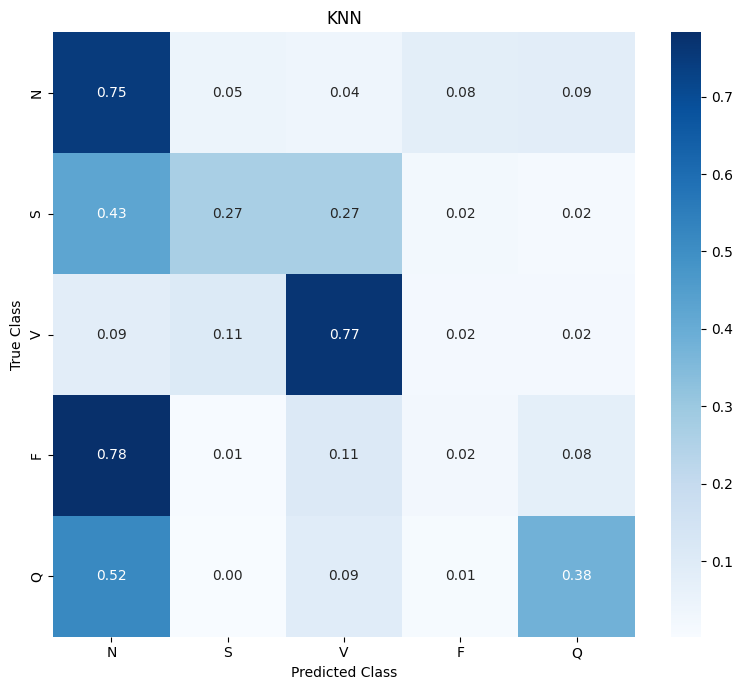

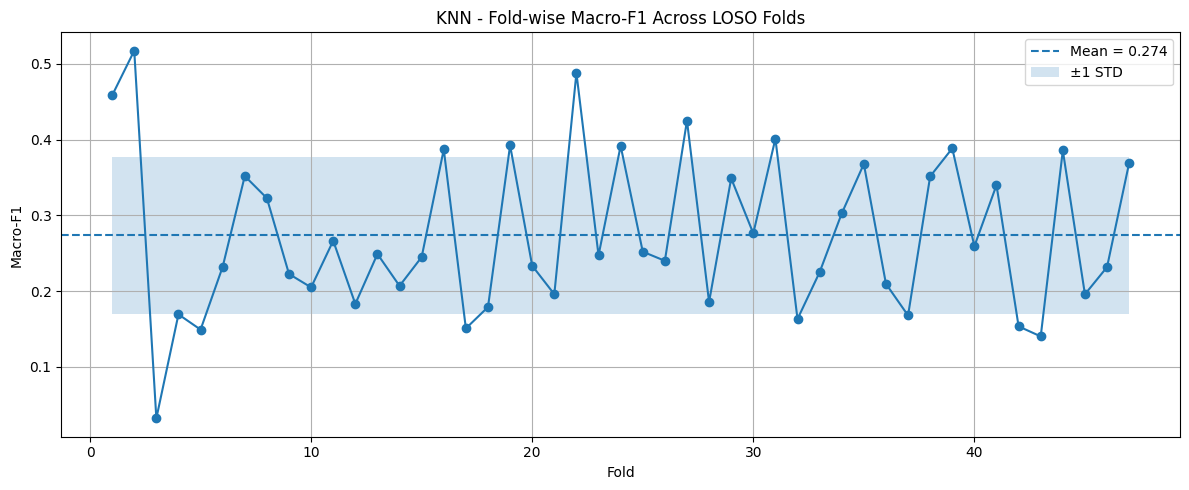

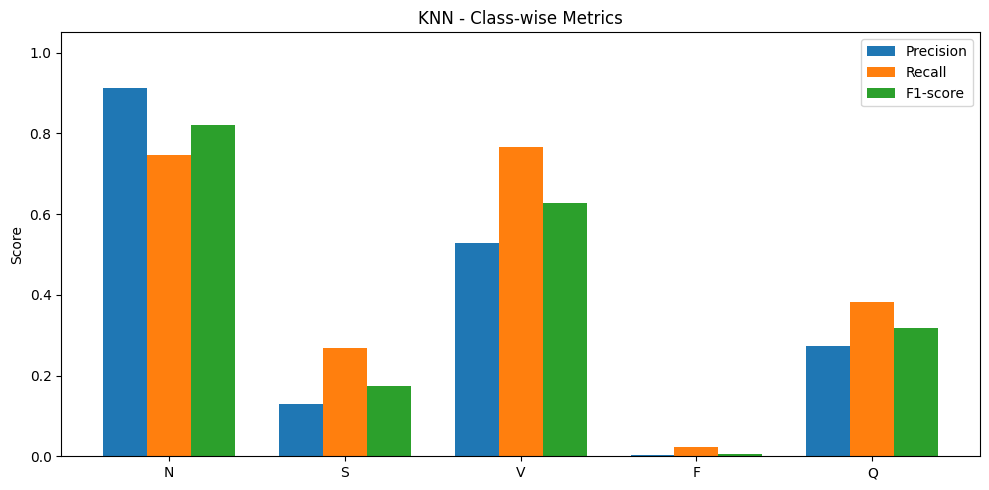

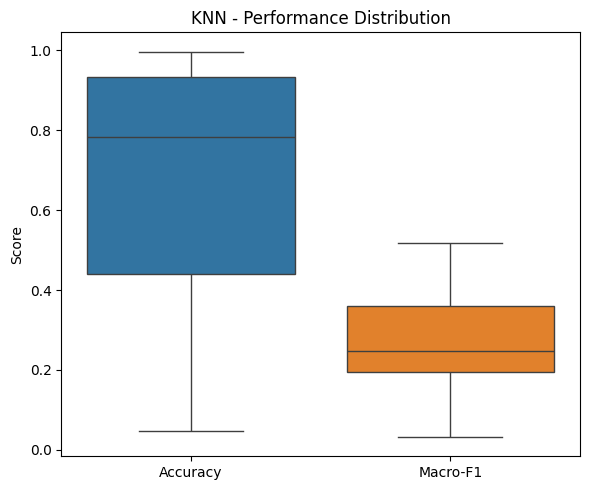

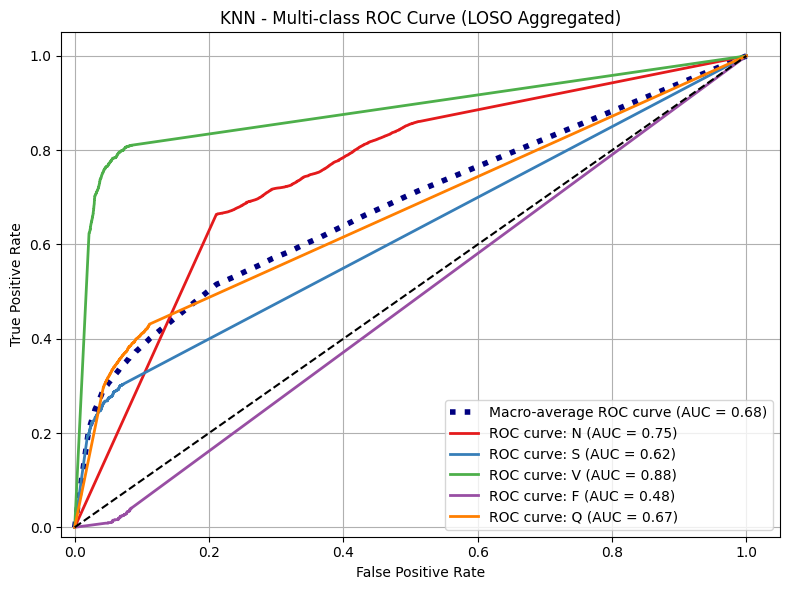

Saved: results_knn_dual_scale/roc_auc.json

FINAL LOSO PERFORMANCE
Overall Accuracy : 0.7037
Overall Macro-F1 : 0.3888
Mean Fold Accuracy : 0.7001 ± 0.2697
Mean Fold Macro-F1 : 0.2736 ± 0.1040
Macro ROC-AUC : 0.6803

All KNN results saved in: results_knn_dual_scale/


In [7]:
# ============================================================
# STEP-06: Aggregate LOSO Results + Visualization (KNN)
# ============================================================

import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize


# ============================================================
# Configuration
# ============================================================

RESULTS_DIR = "results_knn_dual_scale"

CLASS_LABELS = [0, 1, 2, 3, 4]

# CLASS_NAMES must already exist from the previous notebook/step.
# Example:
# CLASS_NAMES = ["N", "S", "V", "F", "Q"]


# ============================================================
# Create output directory
# ============================================================

os.makedirs(RESULTS_DIR, exist_ok=True)


# ============================================================
# Aggregate predictions and probabilities
# ============================================================

all_preds = np.concatenate([
    np.asarray(r["preds"])
    for r in all_results
])

all_labels = np.concatenate([
    np.asarray(r["labels"])
    for r in all_results
])

all_probs = np.concatenate([
    np.asarray(r["probs"])
    for r in all_results
])


# ============================================================
# Safety Check
# ============================================================

print("=" * 60)
print("STEP-06: KNN LOSO RESULT AGGREGATION")
print("=" * 60)

print(f"Total predictions : {len(all_preds)}")
print(f"Total labels      : {len(all_labels)}")
print(f"Probability shape : {all_probs.shape}")

if len(all_preds) != len(all_labels):
    raise ValueError(
        "Number of predictions does not match number of labels."
    )

if len(all_preds) != len(all_probs):
    raise ValueError(
        "Number of predictions does not match number of probability rows."
    )

if all_probs.shape[1] != 5:
    raise ValueError(
        f"Expected probability shape (N, 5), "
        f"but received {all_probs.shape}."
    )


# ============================================================
# Overall Metrics — TRUE LOSO Metrics
# ============================================================

overall_acc = accuracy_score(
    all_labels,
    all_preds
)

overall_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)


# ============================================================
# Classification Report
# ============================================================

report_dict = classification_report(
    all_labels,
    all_preds,
    labels=CLASS_LABELS,
    target_names=CLASS_NAMES,
    zero_division=0,
    output_dict=True
)


# ============================================================
# Aggregate Confusion Matrix
# ============================================================

agg_cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=CLASS_LABELS
)


# ============================================================
# Print Overall LOSO Results
# ============================================================

print("\n" + "=" * 60)
print("KNN — OVERALL LOSO RESULTS")
print("=" * 60)

print(f"Overall Accuracy : {overall_acc:.4f}")
print(f"Overall Macro-F1 : {overall_f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        all_labels,
        all_preds,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)


# ============================================================
# Fold Statistics
# ============================================================

fold_accuracies = [
    r["accuracy"]
    for r in all_results
]

fold_macro_f1s = [
    r["macro_f1"]
    for r in all_results
]

fold_nums = [
    r["fold"]
    for r in all_results
]


# Mean and Standard Deviation

mean_acc = float(
    np.mean(fold_accuracies)
)

std_acc = float(
    np.std(fold_accuracies)
)

mean_f1 = float(
    np.mean(fold_macro_f1s)
)

std_f1 = float(
    np.std(fold_macro_f1s)
)


# KNN statistics

mean_k = float(
    np.mean([
        r["n_neighbors"]
        for r in all_results
    ])
)

mean_n_samples_fit = float(
    np.mean([
        r["n_samples_fit"]
        for r in all_results
    ])
)


# ============================================================
# Save Complete Fold Results
# ============================================================

all_results_path = os.path.join(
    RESULTS_DIR,
    "all_results.pkl"
)

with open(
    all_results_path,
    "wb"
) as f:

    pickle.dump(
        all_results,
        f
    )

print(
    f"Saved: {all_results_path}"
)


# ============================================================
# Save Summary JSON
# ============================================================

summary = {

    "model":
        "KNeighborsClassifier",

    "evaluation":
        "Patient-Independent LOSO",

    "feature_representation":
        "Dual-Scale",

    "overall_accuracy":
        float(overall_acc),

    "overall_macro_f1":
        float(overall_f1),

    "mean_fold_accuracy":
        mean_acc,

    "std_fold_accuracy":
        std_acc,

    "mean_fold_macro_f1":
        mean_f1,

    "std_fold_macro_f1":
        std_f1,

    "classification_report":
        report_dict,

    "aggregate_confusion_matrix":
        agg_cm.tolist(),

    "fold_accuracies":
        fold_accuracies,

    "fold_macro_f1s":
        fold_macro_f1s,

    "mean_n_neighbors":
        mean_k,

    "mean_n_samples_fit":
        mean_n_samples_fit
}


summary_path = os.path.join(
    RESULTS_DIR,
    "summary.json"
)

with open(
    summary_path,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

print(
    f"Saved: {summary_path}"
)


# ============================================================
# Plot 1: Normalized Confusion Matrix
# ============================================================

cm_row_sums = agg_cm.sum(
    axis=1,
    keepdims=True
)

cm_norm = np.divide(
    agg_cm.astype(np.float64),
    cm_row_sums,
    out=np.zeros_like(
        agg_cm,
        dtype=np.float64
    ),
    where=cm_row_sums != 0
)


plt.figure(
    figsize=(8, 7)
)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title(
    "KNN"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Plot 2: Fold-wise Macro-F1
# ============================================================

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    fold_nums,
    fold_macro_f1s,
    marker="o"
)

plt.axhline(
    mean_f1,
    linestyle="--",
    label=f"Mean = {mean_f1:.3f}"
)

plt.fill_between(
    fold_nums,
    mean_f1 - std_f1,
    mean_f1 + std_f1,
    alpha=0.20,
    label="±1 STD"
)

plt.title(
    "KNN - Fold-wise Macro-F1 Across LOSO Folds"
)

plt.xlabel(
    "Fold"
)

plt.ylabel(
    "Macro-F1"
)

plt.grid(
    True
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "fold_macro_f1.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Plot 3: Class-wise Precision / Recall / F1
# ============================================================

precision = [
    report_dict[c]["precision"]
    for c in CLASS_NAMES
]

recall = [
    report_dict[c]["recall"]
    for c in CLASS_NAMES
]

f1_scores = [
    report_dict[c]["f1-score"]
    for c in CLASS_NAMES
]


x = np.arange(
    len(CLASS_NAMES)
)

w = 0.25


plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x - w,
    precision,
    width=w,
    label="Precision"
)

plt.bar(
    x,
    recall,
    width=w,
    label="Recall"
)

plt.bar(
    x + w,
    f1_scores,
    width=w,
    label="F1-score"
)

plt.xticks(
    x,
    CLASS_NAMES
)

plt.ylim(
    0,
    1.05
)

plt.ylabel(
    "Score"
)

plt.title(
    "KNN - Class-wise Metrics"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "classwise_metrics.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Plot 4: Performance Distribution
# ============================================================

df = pd.DataFrame({
    "Accuracy": fold_accuracies,
    "Macro-F1": fold_macro_f1s
})


plt.figure(
    figsize=(6, 5)
)

sns.boxplot(
    data=df
)

plt.title(
    "KNN - Performance Distribution"
)

plt.ylabel(
    "Score"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "performance_boxplot.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Plot 5: Multi-class ROC Curve
# One-vs-Rest — LOSO Aggregated
# ============================================================

classes = CLASS_LABELS

all_labels_bin = label_binarize(
    all_labels,
    classes=classes
)

n_classes = all_labels_bin.shape[1]


fpr = {}
tpr = {}
roc_auc = {}


# ------------------------------------------------------------
# Class-wise ROC
# ------------------------------------------------------------

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        all_labels_bin[:, i],
        all_probs[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )


# ------------------------------------------------------------
# Macro-average ROC
# ------------------------------------------------------------

all_fpr = np.unique(
    np.concatenate([
        fpr[i]
        for i in range(n_classes)
    ])
)

mean_tpr = np.zeros_like(
    all_fpr
)


for i in range(n_classes):

    mean_tpr += np.interp(
        all_fpr,
        fpr[i],
        tpr[i]
    )


mean_tpr /= n_classes


fpr["macro"] = all_fpr

tpr["macro"] = mean_tpr

roc_auc["macro"] = auc(
    fpr["macro"],
    tpr["macro"]
)


# ------------------------------------------------------------
# Plot ROC
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)


# Macro-average

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label=(
        f"Macro-average ROC curve "
        f"(AUC = {roc_auc['macro']:.2f})"
    ),
    color="navy",
    linestyle=":",
    linewidth=4
)


# Class-specific curves

colors = sns.color_palette(
    "Set1",
    n_classes
)


for i, color in zip(
    range(n_classes),
    colors
):

    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=(
            f"ROC curve: {CLASS_NAMES[i]} "
            f"(AUC = {roc_auc[i]:.2f})"
        )
    )


# Random classifier reference

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    lw=1.5
)


plt.xlim(
    [-0.02, 1.05]
)

plt.ylim(
    [-0.02, 1.05]
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "KNN - Multi-class ROC Curve (LOSO Aggregated)"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    True
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "roc_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Save ROC-AUC Results
# ============================================================

roc_summary = {
    "class_auc": {
        CLASS_NAMES[i]:
            float(roc_auc[i])
        for i in range(n_classes)
    },

    "macro_auc":
        float(roc_auc["macro"])
}


roc_path = os.path.join(
    RESULTS_DIR,
    "roc_auc.json"
)

with open(
    roc_path,
    "w"
) as f:

    json.dump(
        roc_summary,
        f,
        indent=2
    )

print(
    f"Saved: {roc_path}"
)


# ============================================================
# FINAL LOSO PERFORMANCE
# ============================================================

print("\n" + "=" * 60)
print("FINAL LOSO PERFORMANCE")
print("=" * 60)

print(
    f"Overall Accuracy : "
    f"{overall_acc:.4f}"
)

print(
    f"Overall Macro-F1 : "
    f"{overall_f1:.4f}"
)

print(
    f"Mean Fold Accuracy : "
    f"{mean_acc:.4f} ± {std_acc:.4f}"
)

print(
    f"Mean Fold Macro-F1 : "
    f"{mean_f1:.4f} ± {std_f1:.4f}"
)

print(
    f"Macro ROC-AUC : "
    f"{roc_auc['macro']:.4f}"
)

print("=" * 60)

print(
    f"\nAll KNN results saved in: "
    f"{RESULTS_DIR}/"
)